#### Workflow Objectives: 

* **Quantification**: Pseudo-align processed reads to the human reference transcriptome using Kallisto (v0.46.0) and import transcript-level quantification data using TxImport 1.32.0.
* **Filtering and Normalization**: Low-abundance genes were filtered, and expression values will be normalized using the Trimmed Mean of M-values (TMM) method in edgeR 3.38.4.

#### Data Processing & Implementation

Read alignment and processing steps can be submitted to the HPC cluster using the **SLURM scheduler** (default: 4 GB memory, 1 CPU, 6-hour runtime). All subsequent downstream statistical analysis are executed within the R/RStudio environment.

#### Step 1: Pseudo-alignment 

Quantifies transcript abundances directly against the human reference transcriptome.

In [ ]:
#!/bin/sh
# Script for pseudo-alignment and quantification

# Assumes:
#  - Conda is initialized, and an environment named 'python3.7' contains both kallisto and multiqc.
#  - Trimmed paired-end FASTQ files are located in ./trimmomatic_results/ and follow the naming convention *_R1_001_paired.fastq.gz and *_R2_001_paired.fastq.gz.
#  - A pre-built Kallisto index for the human transcriptome exists at ./reference/Homo_sapiens.GRCh38.cdna.all.index.
#  - The script is executed via a SLURM workload manager (e.g., using sbatch), which generates slurm-*.out log files in the current working directory for MultiQC to parse.

conda activate python3.7
mkdir -p kallisto_results

for f in $(ls ./trimmomatic_results/*_paired.fastq.gz | sed 's/.*_results\///' | sed 's/_R.*//' | sort -u)
do
    kallisto quant -i ./reference/Homo_sapiens.GRCh38.cdna.all.index \
    -o ./kallisto_results/${f} ./trimmomatic_results/${f}_R1_001_paired.fastq.gz ./trimmomatic_results/${f}_R2_001_paired.fastq.gz
done

multiqc ./slurm-*.out -p -o ./kallisto_results/.
conda deactivate

All samples show high alignment rates (90–93%) with fragment lengths mostly between 255–311 bp, indicating robust Kallisto quantification.  

<img src="https://www.dropbox.com/scl/fi/s0kv37hwkxhv6m559capj/kallisto_alignment-edited.png?rlkey=tnveodqaqktrozp7lmx9vhabk&st=cz7sux18&raw=1" width=500>




#### Step 2: TxImport
Import and aggregate the resulting transcript-level abundance estimates into gene-level count matrices, preparing the datasets for the downstream statistical analysis.

In [ ]:
# Read experimental metadata (sample names, groups, covariates)
targets <- read.delim("sample_design.txt", sep = "\t", stringsAsFactors = FALSE)
targets

SampleNo,SampleID,Treatment,Passage.Generation,Replicate
<chr>,<chr>,<chr>,<chr>,<chr>
Sample1,NS,Unstm,organoids,Replicate_1
Sample2,NS,Unstm,organoids,Replicate_2
Sample3,NS,Unstm,organoids,Replicate_3
Sample4,NS,Unstm,organoids,Replicate_4
Sample5,IL13,Trtd,organoids,Replicate_1
Sample6,IL13,Trtd,organoids,Replicate_2
Sample7,IL13,Trtd,organoids,Replicate_3
Sample8,IL13,Trtd,organoids,Replicate_4
Sample9,NSNS,Unstm_Unstm,monolayers to organoids,Replicate_1


In [ ]:
# Load required packages
library(rhdf5) # provides functions for handling hdf5 file formats (kallisto outputs bootstraps in this format)
library(tidyverse) # provides access to Hadley Wickham's collection of R packages for data science, which we will use throughout the course
library(tximport) # package for getting Kallisto results into R
library(ensembldb) # helps deal with ensembl
library(EnsDb.Hsapiens.v86) # replace with your organism-specific database package

# Build the Transcript-to-Gene Mapping
Tx <- transcripts(EnsDb.Hsapiens.v86, columns=c("tx_id", "gene_name"))
Tx <- as_tibble(Tx)
Tx <- dplyr::rename(Tx, target_id = tx_id)
Tx <- dplyr::select(Tx, "target_id", "gene_name")

# Import & Aggregate Quantifications with tximport
Txi <- tximport(file.path("kallisto_results", targets$SampleNo, 
                               "abundance.tsv"),
                          type = "kallisto", 
                          tx2gene = Tx, 
                          txOut = F, #determines whether your data represented at transcript or gene level
                          countsFromAbundance = "lengthScaledTPM",
                          ignoreTxVersion = T)

# Verify Imported Data Structure
head(Txi, n = 1)

Note: importing `abundance.h5` is typically faster than `abundance.tsv`

reading in files with read_tsv

1 
2 
3 
4 
5 
6 
7 
8 
9 
10 
11 
12 
13 
14 
15 
16 
17 
18 
19 
20 


transcripts missing from tx2gene: 23314

summarizing abundance

summarizing counts

summarizing length



5S_rRNA,0.0000000,0.0000000,0.0000000,0.00000000,0.00000000,0.0000000,0.00000000,0.0000000,0.000000e+00,0.0000000,0.0000000,0.00000000,0.000000,0.0000000,0.0000000,0.0000000,0.00000000,0.0000000,0.0000000,0.00000000
A1BG,9.3194784,11.9432374,7.1106548,3.13214600,14.50751200,14.5239480,10.93812360,11.3618440,1.044994e+01,11.5252670,11.7890600,9.63497540,8.729064,12.9714507,11.8641839,10.4750990,19.13882310,15.4722923,14.1580630,18.34211960
A1CF,0.0000000,0.1301500,0.0000000,0.00699594,0.01953674,0.0000000,0.03974866,0.0000000,6.716721e-03,0.0000000,0.0000000,0.03217782,0.000000,0.0000000,0.0000000,0.0000000,0.01262216,0.0000000,0.0000000,0.01774522
A2M,0.0000000,0.0000000,0.0000000,0.00000000,0.00000000,0.0000000,0.00000000,0.2238940,1.385760e-02,0.0253939,0.1136250,0.02561400,0.000000,0.2301351,0.1892880,0.3426371,0.00000000,0.2410960,0.0000000,0.00000000
A2ML1,297.0734460,246.6327220,238.9795050,280.46943100,186.84323900,173.1646900,155.68502900,212.5859470,1.375588e+02,205.9411350,150.0682630,191.81108000,224.940391,260.3177890,218.5551900,236.8191350,109.13296400,104.0349420,107.1345690,116.26326100
A2MP1,0.0000000,0.0000000,0.0000000,0.00000000,0.00000000,0.0000000,0.00000000,0.0000000,0.000000e+00,0.0000000,0.0000000,0.00000000,0.000000,0.0000000,0.0000000,0.0000000,0.00000000,0.0000000,0.0000000,0.00000000
A3GALT2,0.0000000,0.0000000,0.0000000,0.00000000,0.00000000,0.0000000,0.00000000,0.0000000,0.000000e+00,0.0000000,0.0697055,0.00000000,0.000000,0.0000000,0.0000000,0.0749833,0.00000000,0.0000000,0.0000000,0.06967180
A4GALT,4.7222440,5.9888210,4.5365410,7.52428000,14.13784200,10.2879203,11.67717100,7.9608940,3.521865e+00,3.3340040,1.4762630,1.64058693,2.369148,2.3993910,2.4203760,6.2039980,7.62939600,7.3923954,10.3550100,7.75229400
A4GNT,0.0000000,0.0286219,0.0422979,0.04171240,0.00000000,0.0000000,0.00000000,0.0000000,0.000000e+00,0.0728483,0.0000000,0.00000000,0.000000,0.0000000,0.0433755,0.0000000,0.00000000,0.0000000,0.0000000,0.00000000
AAAS,40.4946230,40.2227250,33.8034163,30.48814200,35.77393500,31.9466153,36.82442908,33.1267391,2.359588e+01,25.2027070,21.9766616,21.25818780,24.519588,26.5361543,27.8102419,27.5153320,37.67634700,32.3276509,29.9088220,30.41928355
AACS,15.9379946,16.7239722,16.3998112,12.92615521,24.03235900,23.4122390,21.30827100,19.5365059,1.387381e+01,19.0164974,14.5781189,17.47332470,17.806273,17.1727373,19.5257852,20.1480630,20.05329750,19.6163983,18.7206854,20.77864090


#### Step 3: Data wrangling
Filter out low-abundance genes to reduce computational noise and improve statistical power, then normalize the remaining expression values to account for composition bias.

Warning message:
"package 'edgeR' was built under R version 4.4.1"
Loading required package: limma

Warning message:
"package 'limma' was built under R version 4.4.1"

Attaching package: 'limma'


The following object is masked from 'package:BiocGenerics':

    plotMA


Warning message:
"package 'matrixStats' was built under R version 4.4.2"

Attaching package: 'matrixStats'


The following objects are masked from 'package:Biobase':

    anyMissing, rowMedians


The following object is masked from 'package:dplyr':

    count




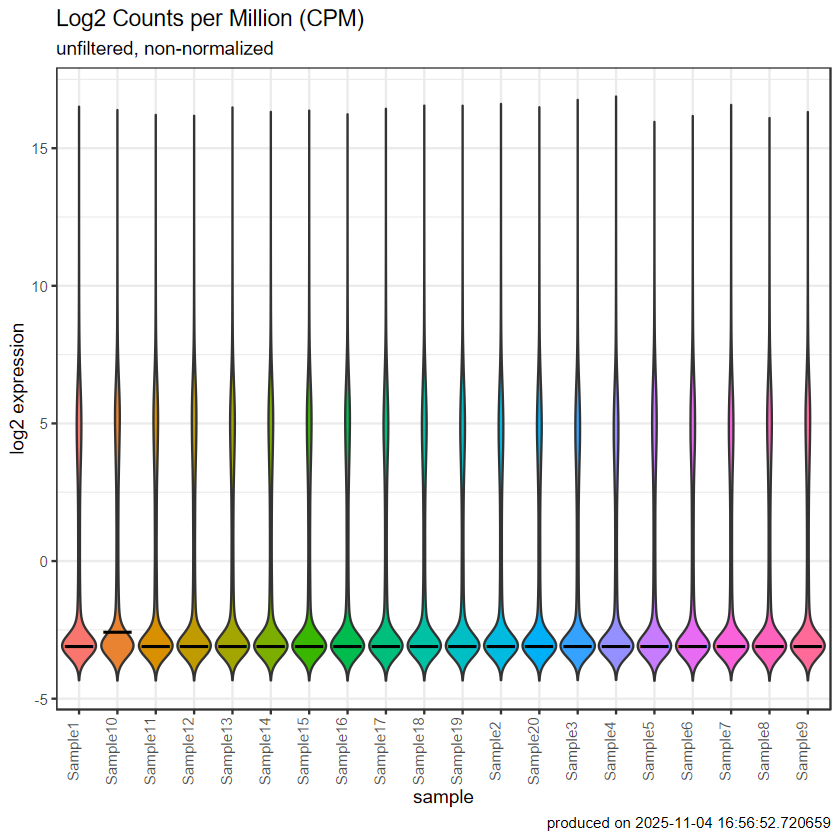

In [ ]:
## Setup DGEList and Compute Log2 CPM (Unfiltered, Non-Normalized)

library(edgeR) # well known package for differential expression analysis, but we only use for the DGEList object and for normalization methods
library(matrixStats) # let's us easily calculate stats on rows or columns of a data matrix

# Extract sample labels from metadata
sampleLabels <- targets$SampleNo

# Initialize the edgeR DGEList object using the raw count matrix from tximport
myDGEList <- DGEList(Txi$counts)

# Compute log2-transformed Counts Per Million (log2-CPM)
log2.cpm <- cpm(myDGEList, log=T)

# # Convert the matrix to a tibble, assign sample names as column headers, and pivot into a long format suitable for ggplot2 mapping.
log2.cpm.df <- as_tibble(log2.cpm, rownames = "geneID")
colnames(log2.cpm.df) <- c("geneID", sampleLabels)
log2.cpm.df.pivot <- pivot_longer(log2.cpm.df, # dataframe to be pivoted
                                  cols = colnames(log2.cpm.df[-1]), # column names to be stored as a SINGLE variable
                                  names_to = "samples", # name of that new variable (column)
                                  values_to = "expression") # name of new variable (column) storing all the values (data)

# Violin Plot of Log2 CPM Distributions
p1 <- ggplot(log2.cpm.df.pivot) +
  aes(x=samples, y=expression, fill=samples) +
  geom_violin(trim = F, show.legend = F) +
  stat_summary(fun = "median", 
               geom = "point", 
               shape = 95, 
               size = 10, 
               color = "black", 
               show.legend = F) +
  labs(y="log2 expression", x = "sample",
       title="Log2 Counts per Million (CPM)",
       subtitle="unfiltered, non-normalized",
       caption=paste0("produced on ", Sys.time())) +
  theme_bw() +
  theme(axis.text.x = element_text(angle = 90, vjust = -0.05))

p1

The plot reveals a massive population of low-abundance genes (the large bottom bulges) representing technical background noise, alongside subtle sample-to-sample variations driven by differences in sequencing depth.

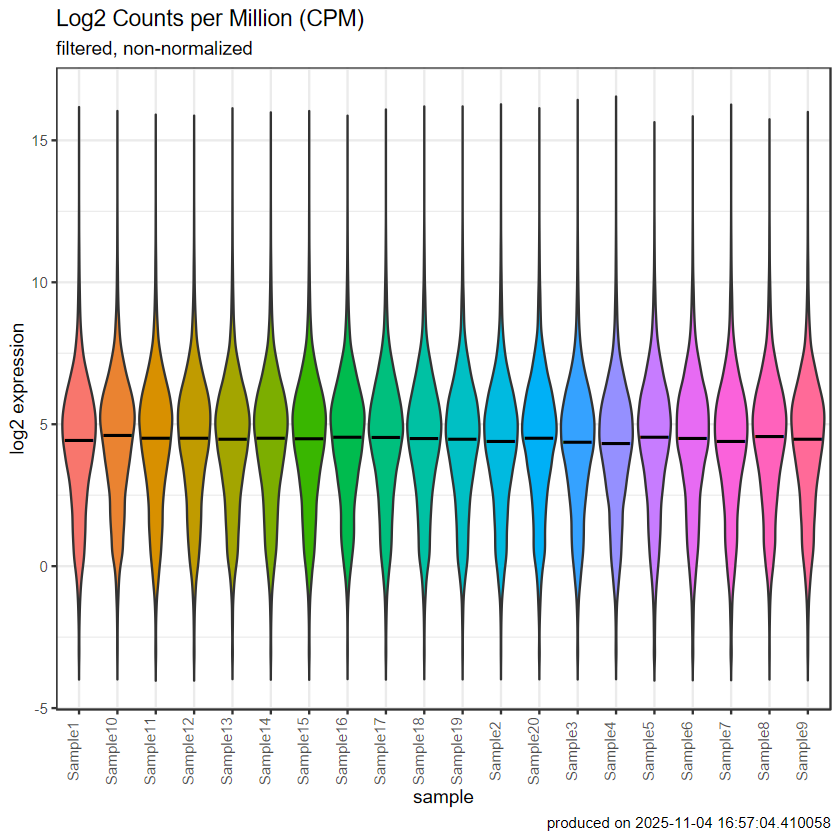

In [ ]:
## Setup Filtering & Compute Log2 CPM (filtered, non-normalized)

# Calculate CPM on raw counts to determine which genes to keep
cpm <- cpm(myDGEList)
keepers <- rowSums(cpm>1)>=5 #user defined
myDGEList.filtered <- myDGEList[keepers,]

# Calculate log2-transformed CPM on the filtered dataset
log2.cpm.filtered <- cpm(myDGEList.filtered, log=T)
log2.cpm.filtered.df <- as_tibble(log2.cpm.filtered, rownames = "geneID")
colnames(log2.cpm.filtered.df) <- c("geneID", sampleLabels)

# Convert to tibble, rename columns dynamically, and pivot to long format
log2.cpm.filtered.df.pivot <- pivot_longer(log2.cpm.filtered.df, # dataframe to be pivoted
                                           cols = colnames(log2.cpm.df[-1]), # column names to be stored as a SINGLE variable
                                           names_to = "samples", # name of that new variable (column)
                                           values_to = "expression") # name of new variable (column) storing all the values (data)

# Violin Plot of Filtered, Non-Normalized Distributions
p2 <- ggplot(log2.cpm.filtered.df.pivot) +
  aes(x=samples, y=expression, fill=samples) +
  geom_violin(trim = F, show.legend = F) +
  stat_summary(fun = "median", 
               geom = "point", 
               shape = 95, 
               size = 10, 
               color = "black", 
               show.legend = F) +
  labs(y="log2 expression", x = "sample",
       title="Log2 Counts per Million (CPM)",
       subtitle="filtered, non-normalized",
       caption=paste0("produced on ", Sys.time())) +
  theme_bw() +
  theme(axis.text.x = element_text(angle = 90, vjust = -0.05))

p2


Filtering has eliminated the low-expression background noise, removing the bottom bulges and shifting the median expression levels upward to approximately 4.5. However, minor vertical offsets still persist between individual sample distributions due to differences in sequencing depth and library composition.

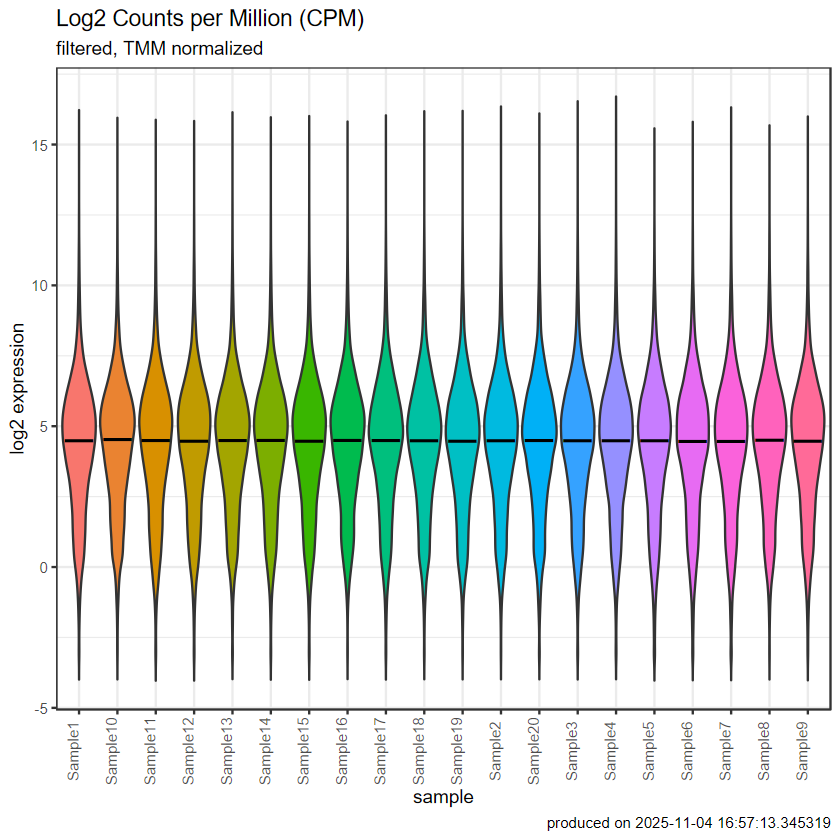

In [ ]:
## Setup TMM normalization and Compute Log2 CPM

# Calculate TMM normalization factors to scale library sizes
myDGEList.filtered.norm <- calcNormFactors(myDGEList.filtered, method = "TMM")

# Compute normalized log2-CPM values using the calculated normalization factors
log2.cpm.filtered.norm <- cpm(myDGEList.filtered.norm, log=T)

# # Convert the matrix to a tibble, rename columns dynamically, and pivot to long format
log2.cpm.filtered.norm.df <- as_tibble(log2.cpm.filtered.norm, rownames = "geneID")
colnames(log2.cpm.filtered.norm.df) <- c("geneID", sampleLabels)
log2.cpm.filtered.norm.df.pivot <- pivot_longer(log2.cpm.filtered.norm.df, # dataframe to be pivoted
                                                cols = colnames(log2.cpm.df[-1]), # column names to be stored as a SINGLE variable
                                                names_to = "samples", # name of that new variable (column)
                                                values_to = "expression") # name of new variable (column) storing all the values (data)


# Violin Plot of Filtered, TMM-Normalized Distributions
p3 <- ggplot(log2.cpm.filtered.norm.df.pivot) +
  aes(x=samples, y=expression, fill=samples) +
  geom_violin(trim = F, show.legend = F) +
  stat_summary(fun = "median", 
               geom = "point", 
               shape = 95, 
               size = 10, 
               color = "black", 
               show.legend = F) +
  labs(y="log2 expression", x = "sample",
       title="Log2 Counts per Million (CPM)",
       subtitle="filtered, TMM normalized",
       caption=paste0("produced on ", Sys.time())) +
  theme_bw() +
  theme(axis.text.x = element_text(angle = 90, vjust = -0.05))

p3

TMM normalization has eliminated compositional biases and sequencing depth discrepancies, bringing the sample medians into near-perfect horizontal alignment.

### Summary of 
* **Quantification & Aggregation**: Transcript abundances were pseudo-aligned against the human reference transcriptome and successfully imported and aggregated into gene-level count matrices, resolving transcript-to-gene mapping to prepare the dataset for downstream differential expression.
* **Robust Pre-Processing & Normalization**: Step-by-step diagnostic visualizations using violin plots demonstrated that filtering out low-abundance genes successfully eliminated background technical noise. Subsequent TMM normalization corrected for sequencing depth and compositional biases.
* **Next Steps**: Sample clustering, group-to-group variability, and identification of potential outliers will be assessed via PCA, and differential expression will be analyzed. 